##Unsupervised learning


In [302]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (classification_report, 
                            confusion_matrix, 
                            RocCurveDisplay)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score
from joblib import load


In [303]:
df_training = load('df_training.joblib')

In [304]:
df_training.head()

,OverTime,TotalWorkingYears,JobLevel,MaritalStatus,YearsInCurrentRole,MonthlyIncome,Age,YearsWithCurrManager,StockOptionLevel,YearsAtCompany,JobInvolvement,JobSatisfaction,EnvironmentSatisfaction,Attrition
0,1,8,2,0,4,5993,41,5,0,6,3,4,2,1
1,0,10,2,1,7,5130,49,7,1,10,2,2,3,0
2,1,7,1,0,0,2090,37,0,0,0,2,3,4,1
3,1,8,1,1,7,2909,33,0,0,8,3,3,4,0
4,0,6,1,1,2,3468,27,2,1,2,3,2,1,0


In [305]:
df_training.isnull().sum()

OverTime                   0
TotalWorkingYears          0
JobLevel                   0
MaritalStatus              0
YearsInCurrentRole         0
MonthlyIncome              0
Age                        0
YearsWithCurrManager       0
StockOptionLevel           0
YearsAtCompany             0
JobInvolvement             0
JobSatisfaction            0
EnvironmentSatisfaction    0
Attrition                  0
dtype: int64

#Train-Test Split

In [306]:
X = df_training.iloc[:,:-6]
y = df_training.iloc[:,-1]

#normalize the datase

In [307]:
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

#split dataset in training anf test

In [308]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

#Train Random Forest

In [309]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 0.8]  # Added to prevent overfitting
}

rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=42
)

grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_

In [310]:
y_pred = best_rf.predict(X_test)

# Calculate accuracy
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Accuracy: 0.7989


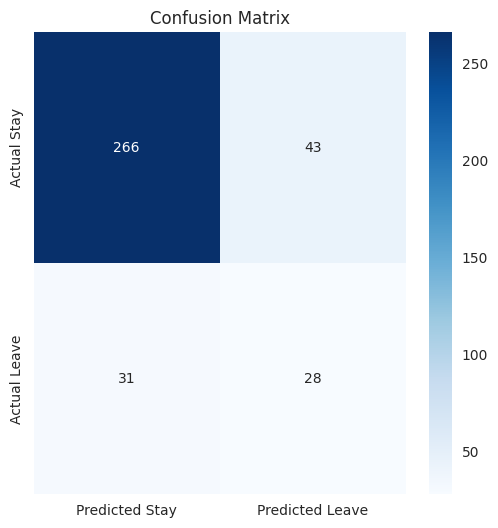

In [311]:
# 1. Confusion Matrix
plt.figure(figsize=(6,6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Stay', 'Predicted Leave'],
            yticklabels=['Actual Stay', 'Actual Leave'])
plt.title('Confusion Matrix')
plt.show()

In [312]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.86      0.88       309
           1       0.39      0.47      0.43        59

    accuracy                           0.80       368
   macro avg       0.64      0.67      0.65       368
weighted avg       0.82      0.80      0.81       368



<Figure size 600x600 with 0 Axes>

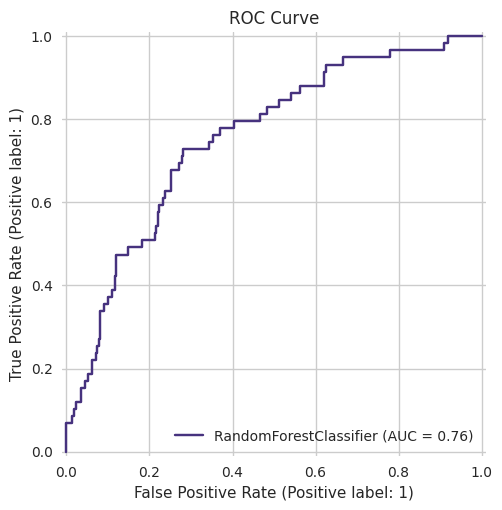

In [313]:
plt.figure(figsize=(6,6))
RocCurveDisplay.from_estimator(best_rf, X_test, y_test)
plt.title('ROC Curve')
plt.show()

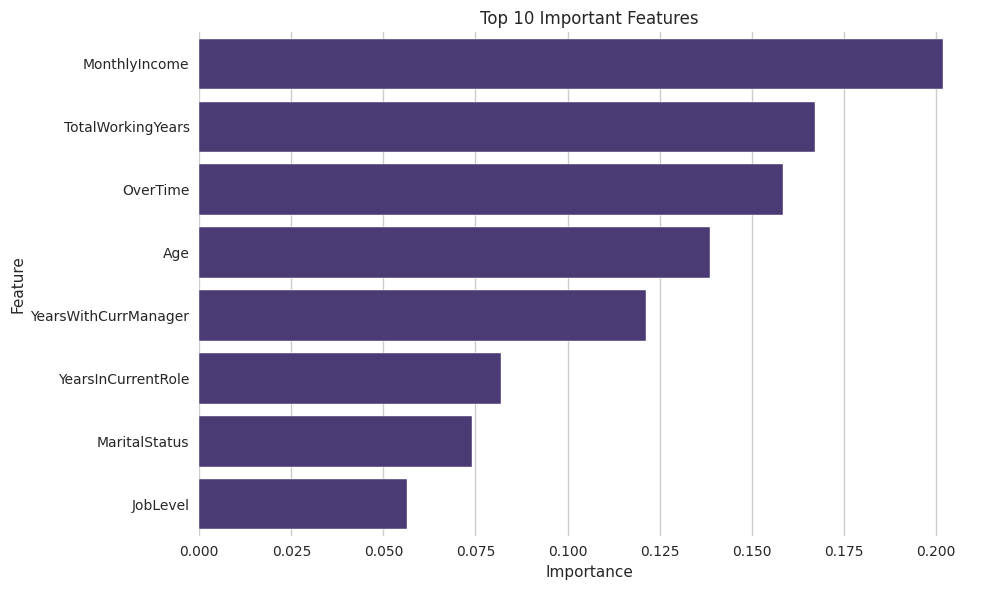

In [314]:
importance = pd.DataFrame({
    'Feature': df_training.columns[:-6],  # Use your original feature names
    'Importance': best_rf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=importance.head(10), x='Importance', y='Feature')
plt.title('Top 10 Important Features')
plt.tight_layout()
plt.show()

In [315]:
from sklearn.metrics import recall_score

recall = recall_score(y_test, y_pred)
print(f"\nRecall Score: {recall:.2%} of actual attrition cases were correctly identified")

# Show what recall means in employee counts
true_positives = confusion_matrix(y_test, y_pred)[1, 1]
actual_positives = y_test.sum()
print(f"\nIdentified {true_positives} out of {actual_positives} actual attrition cases")


Recall Score: 47.46% of actual attrition cases were correctly identified

Identified 28 out of 59 actual attrition cases
